# Sen1Floods11 sample gallery — 12 samples per collection

**36 chips · 12 figure pages · explicit selection tables.** Run this notebook directly with your Python/Jupyter kernel using **Run All**. The rendered plots are also saved below. Settings are in the next code cell; the section **How the images are selected** explains the sampling.

The local download contains **one dataset, Sen1Floods11 v1.1**, with several image/label collections used by the baseline experiments:

| Collection | Input | Target |
| --- | --- | --- |
| Hand-labelled flood events | Sentinel-1 VV/VH | Human-labelled water mask |
| S1 weak supervision | Sentinel-1 VV/VH | Sentinel-1 Otsu-derived mask |
| S2 weak supervision | Sentinel-1 VV/VH  | Sentinel-2 index-derived mask |
| Permanent water | Sentinel-1 VV/VH | JRC-derived permanent-water mask |

Sentinel-2 RGB is shown as visual context where available. **The S2 weak baseline still uses Sentinel-1 as its model input.** These are source samples and supervision masks, not model predictions.

Run all cells on CPU with NumPy, rasterio and matplotlib installed. No training, downloads or data modifications are performed. Samples come from the available collections across splits; this is visual exploration, not an evaluation subset.

In [1]:
from pathlib import Path
import csv
import textwrap
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Locate the data directly; no experiment runner or repository utility is needed.
# Works from the checkout root, runtime/, or this notebook's folder.
DATASET_ROOT = next(
    (base / relative
     for base in (Path.cwd(), *Path.cwd().parents)
     for relative in (Path("runtime/datasets/Sen1Floods11/v1.1"),
                      Path("datasets/Sen1Floods11/v1.1"))
     if (base / relative / "data/flood_events").is_dir()
     and (base / relative / "data/perm_water").is_dir()),
    None,
)
if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Cannot find Sen1Floods11. Start Jupyter inside the thesis checkout "
        "with the data at runtime/datasets/Sen1Floods11/v1.1/."
    )

N_SAMPLES = 12        # Number of distinct chips PER collection (36 chips in total).
ROWS_PER_FIGURE = 3   # Split each collection into readable pages of three chips.
SEED = 42            # Reproducible selection; change this for different chips.
if not isinstance(N_SAMPLES, int) or N_SAMPLES < 1:
    raise ValueError("N_SAMPLES must be a positive integer.")
if not isinstance(ROWS_PER_FIGURE, int) or ROWS_PER_FIGURE < 1:
    raise ValueError("ROWS_PER_FIGURE must be a positive integer.")

HAND = DATASET_ROOT / "data/flood_events/HandLabeled"
WEAK = DATASET_ROOT / "data/flood_events/WeaklyLabeled"
PERM = DATASET_ROOT / "data/perm_water"

In [2]:
def flood_records(folder, image_suffix, other_suffixes):
    records = []
    for image in sorted((folder / image_suffix).glob(f"*_{image_suffix}.tif")):
        key = image.stem.removesuffix("_" + image_suffix)
        record = {"key": key, "s1": image}
        record.update({name: folder / suffix / f"{key}_{suffix}.tif"
                       for name, suffix in other_suffixes.items()})
        missing = [p.name for name, p in record.items() if name != "key" and not p.is_file()]
        if missing:
            raise FileNotFoundError(f"Unpaired chip {key}: {missing}")
        records.append(record)
    return records

hand_records = flood_records(HAND, "S1Hand", {"rgb": "S2Hand", "mask": "LabelHand"})
weak_records = flood_records(WEAK, "S1Weak", {
    "rgb": "S2Weak", "s1_mask": "S1OtsuLabelWeak", "s2_mask": "S2IndexLabelWeak",
})
perm_records = []
with (DATASET_ROOT / "splits/perm_water/permanent_water_data.csv").open(newline="") as stream:
    for row in csv.reader(stream):
        if not row:
            continue
        image, label = row
        record = {"key": Path(image).stem, "s1": PERM / "S1Perm" / image,
                  "mask": PERM / "JRCPerm" / label}
        if not record["s1"].is_file() or not record["mask"].is_file():
            raise FileNotFoundError(f"Missing permanent-water pair: {image}, {label}")
        perm_records.append(record)

for name, records in [("Hand-labelled", hand_records), ("Weakly labelled (two target types)", weak_records),
                      ("Permanent water", perm_records)]:
    if not records:
        raise ValueError(f"No samples found for {name}.")
    print(f"{name}: {len(records):,} paired samples")

Hand-labelled: 446 paired samples
Weakly labelled (two target types): 4,384 paired samples
Permanent water: 814 paired samples


## How the images are selected

The default is **12 distinct chips per collection**, shown in pages of **3 rows**: 12 hand-labelled chips, 12 weakly labelled chips and 12 permanent-water chips. Each row shows several views of one chip. The two weak masks use the **same 12 chips**, so they can be compared directly.

| Collection | Eligible pool | Selection rule |
| --- | --- | --- |
| Hand-labelled | All paired S1Hand / S2Hand / LabelHand files | Sample across filename region prefixes |
| Weakly labelled | All paired S1Weak / S2Weak / S1OtsuLabelWeak / S2IndexLabelWeak files | Sample across filename region prefixes |
| Permanent water | All pairs listed in `splits/perm_water/permanent_water_data.csv` | Uniform random sample without replacement |

**For flood-event collections**, the code groups chips by the text before the first underscore (`Bolivia_103757` belongs to `Bolivia`). It shuffles the region order and the chips within each region using `SEED`, then takes one chip from each region in turn. If more samples are needed, it takes a second chip from each region, and so on, skipping exhausted groups. If fewer samples than regions are requested, only the first shuffled regions are shown. These are filename groups, not a new geographic split.

**For permanent water**, it shuffles the complete list and takes the first `N_SAMPLES` entries, without repeats. No region balancing is applied.

- The eligible pools include all available splits, including held-out areas. Training exclusions (such as Bolivia for the S2-weak baseline) are not applied to this gallery.
- Selection does **not** inspect water coverage, cloudiness, visual quality or model performance. Empty masks, clouds and missing-data edges can appear. Flood galleries give regions similar representation, rather than following each region's share of the dataset.
- Each collection starts its own random generator with `SEED`. The same files and seed reproduce the same ordering. Increasing `N_SAMPLES` extends that ordering; changing `ROWS_PER_FIGURE` only changes pagination.
- Before each gallery, the notebook prints the exact selected chip IDs and, for flood events, available/selected counts per region. Figure row numbers match that list. The `hand_samples`, `weak_samples` and `perm_samples` variables contain the exact file paths for every displayed panel.

To see different examples, change `SEED` and rerun from the settings cell. Increase `N_SAMPLES` for more chips. This gallery is for inspection, not a representative benchmark sample.


**Pairing checks:** source pairs are displayed as provided, including permanent-water CSV rows. Each displayed raster is checked against its Sentinel-1 image for CRS, shape and transform (allowing tiny rounding differences). A differing grid gets a red border and a warning; it is not silently repaired or filtered out. Such panels show different spatial footprints and should not be interpreted as pixel-aligned targets.

## Display conventions

Each radar band is stretched between its own 2nd and 98th percentiles for display. RGB uses the GeoTIFF's **B4/B3/B2** band descriptions and a shared percentile stretch. These stretches do not change the files or the training preprocessing; brightness is not directly comparable between tiles. Flood-event and permanent-water radar files also have different stored scales.

Masks use **blue = water**, **cream = non-water**, **grey = ignored/no data** (`-1`, `255`, non-finite values or declared nodata). Water in a flood-event mask is not necessarily newly flooded water. Clouds may obscure the optical images.

**Bright magenta marks missing image pixels** in the radar and RGB panels (declared nodata or non-finite values). Black radar pixels are valid low-intensity values after the display stretch. An RGB pixel is magenta if any of its displayed bands is missing. Grey still means an ignored/no-data pixel in a label mask; image validity and label validity are separate.

In [3]:
IMAGE_NODATA_COLOR = "#ff00ff"  # Magenta distinguishes missing imagery from dark returns.
RADAR_CMAP = plt.get_cmap("gray").copy()
RADAR_CMAP.set_bad(IMAGE_NODATA_COLOR)

MASK_COLORS = ["#c6cbd2", "#eee6d4", "#168bd2"]
MASK_CMAP = ListedColormap(MASK_COLORS)
MASK_NORM = BoundaryNorm([-1.5, -0.5, 0.5, 1.5], MASK_CMAP.N)

def choose_samples(records, mode="random"):
    """Return a deterministic ordering without replacement, truncated to N_SAMPLES."""
    rng = np.random.default_rng(SEED)
    records = sorted(records, key=lambda record: record["key"])
    if len({record["key"] for record in records}) != len(records):
        raise ValueError("Duplicate chip IDs in the sampling pool.")
    count = min(N_SAMPLES, len(records))
    if mode == "random":
        return [records[i] for i in rng.permutation(len(records))[:count]]
    if mode != "region_balanced":
        raise ValueError(f"Unknown sampling mode: {mode}")

    # A region here means the filename prefix: e.g. Bolivia_103757 -> Bolivia.
    groups = {}
    for record in records:
        groups.setdefault(record["key"].split("_", 1)[0], []).append(record)
    region_order = list(rng.permutation(sorted(groups)))
    for region in region_order:
        group = groups[region]
        groups[region] = [group[i] for i in rng.permutation(len(group))]

    # First visit: one chip per region. Second visit: another per region, etc.
    # Exhausted groups are skipped. A chip can never be selected twice.
    selected = []
    position = 0
    while len(selected) < count:
        for region in region_order:
            if position < len(groups[region]):
                selected.append(groups[region][position])
                if len(selected) == count:
                    break
        position += 1
    return selected


def describe_selection(pool, selected, mode):
    print(f"Selected {len(selected)} of {len(pool):,} chips | seed={SEED} | method={mode}")
    if len(selected) < N_SAMPLES:
        print("The collection has fewer chips than requested; showing every available chip.")
    if mode == "region_balanced":
        regions = sorted({r["key"].split("_", 1)[0] for r in pool})
        print("\nRegion prefix       Available   Selected")
        for region in regions:
            available = sum(r["key"].split("_", 1)[0] == region for r in pool)
            shown = sum(r["key"].split("_", 1)[0] == region for r in selected)
            print(f"{region:<20}{available:>9}{shown:>11}")
    print("\nRow  Exact chip ID (same order as the figures)")
    for index, record in enumerate(selected, start=1):
        print(f"{index:>3}  {record['key']}")


def read_bands(path, names=None):
    with rasterio.open(path) as src:
        if names is None:
            indices = [1]
        else:
            available = list(src.descriptions)
            if any(name not in available for name in names):
                raise ValueError(f"{path.name}: expected bands {names}, found {available}")
            indices = [available.index(name) + 1 for name in names]
        values = src.read(indices, masked=True).astype(np.float32).filled(np.nan)
        values[~np.isfinite(values)] = np.nan
        return values, (src.crs, src.transform, src.height, src.width)

def stretch(values):
    finite = values[np.isfinite(values)]
    if not finite.size:
        return np.full_like(values, np.nan)
    low, high = np.percentile(finite, [2, 98])
    scaled = np.clip((values - low) / (high - low), 0, 1) if high > low else np.zeros_like(values)
    return np.where(np.isfinite(values), scaled, np.nan)

def show_page(records, columns, title, first_row):
    fig, axes = plt.subplots(len(records), len(columns), figsize=(3.3 * len(columns), 3.2 * len(records)),
                             squeeze=False, layout="constrained")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    for row, record in enumerate(records):
        _, reference_grid = read_bands(record["s1"], ["VV"])
        for col, (field, kind, heading) in enumerate(columns):
            ax = axes[row, col]
            bands = [kind] if kind in ("VV", "VH") else ["B4", "B3", "B2"] if kind == "rgb" else None
            values, grid = read_bands(record[field], bands)
            tolerance = max(abs(reference_grid[1].a), abs(reference_grid[1].e)) * 0.001
            same_grid = (grid[0] == reference_grid[0] and grid[2:] == reference_grid[2:]
                         and grid[1].almost_equals(reference_grid[1], precision=tolerance))
            if not same_grid:
                print(f"PAIRING WARNING: {record['key']} -> {record[field].name}: different spatial grids.")
                ax.set_xlabel("Different spatial grid\nPairing needs review", color="crimson", fontsize=9)
                for spine in ax.spines.values():
                    spine.set_edgecolor("crimson")
                    spine.set_linewidth(2.5)
            if kind == "mask":
                mask = values[0]
                valid = np.isfinite(mask) & ~np.isin(mask, [-1, 255])
                unexpected = np.unique(mask[valid & ~np.isin(mask, [0, 1])])
                if unexpected.size:
                    raise ValueError(f"Unexpected label values in {record[field].name}: {unexpected}")
                ax.imshow(np.where(valid, mask, -1), cmap=MASK_CMAP, norm=MASK_NORM, interpolation="nearest")
            elif kind == "rgb":
                rgb = np.moveaxis(stretch(values), 0, -1)
                # Any missing RGB channel makes that display pixel invalid.
                rgb[~np.isfinite(rgb).all(axis=-1)] = (1.0, 0.0, 1.0)
                ax.imshow(rgb, interpolation="nearest")
            else:
                ax.imshow(np.ma.masked_invalid(stretch(values[0])), cmap=RADAR_CMAP, vmin=0, vmax=1, interpolation="nearest")
            if row == 0:
                ax.set_title(heading, fontsize=11)
            if col == 0:
                short_key = record["key"].removeprefix("sentinel_")
                ax.set_ylabel(f"#{first_row + row}\n" + textwrap.fill(short_key, 28), fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
    fig.legend(handles=[Patch(facecolor=color, label=name) for color, name in
                        zip(MASK_COLORS, ["Label ignored / no data", "Non-water", "Water"])]
               + [Patch(facecolor=IMAGE_NODATA_COLOR, label="Image missing / no data")],
               loc="outside lower center", ncol=4, frameon=False)
    plt.show()
    plt.close(fig)


def show_samples(records, columns, title):
    for start in range(0, len(records), ROWS_PER_FIGURE):
        page = records[start:start + ROWS_PER_FIGURE]
        label = f"{title} | chips {start + 1}-{start + len(page)} of {len(records)} | seed {SEED}"
        show_page(page, columns, label, first_row=start + 1)


## 1. Hand-labelled flood events
Radar input, optical context and the human-labelled target for each chip.

Selected 12 of 446 chips | seed=42 | method=region_balanced

Region prefix       Available   Selected
Bolivia                    15          1
Ghana                      53          1
India                      68          1
Mekong                     30          1
Nigeria                    18          1
Pakistan                   28          1
Paraguay                   67          2
Somalia                    26          1
Spain                      30          1
Sri-Lanka                  42          1
USA                        69          1

Row  Exact chip ID (same order as the figures)
  1  Paraguay_790830
  2  Somalia_1068756
  3  Bolivia_195474
  4  USA_114964
  5  Mekong_1439641
  6  Pakistan_132143
  7  India_698338
  8  Nigeria_984831
  9  Sri-Lanka_847275
 10  Ghana_359826
 11  Spain_7370579
 12  Paraguay_305760


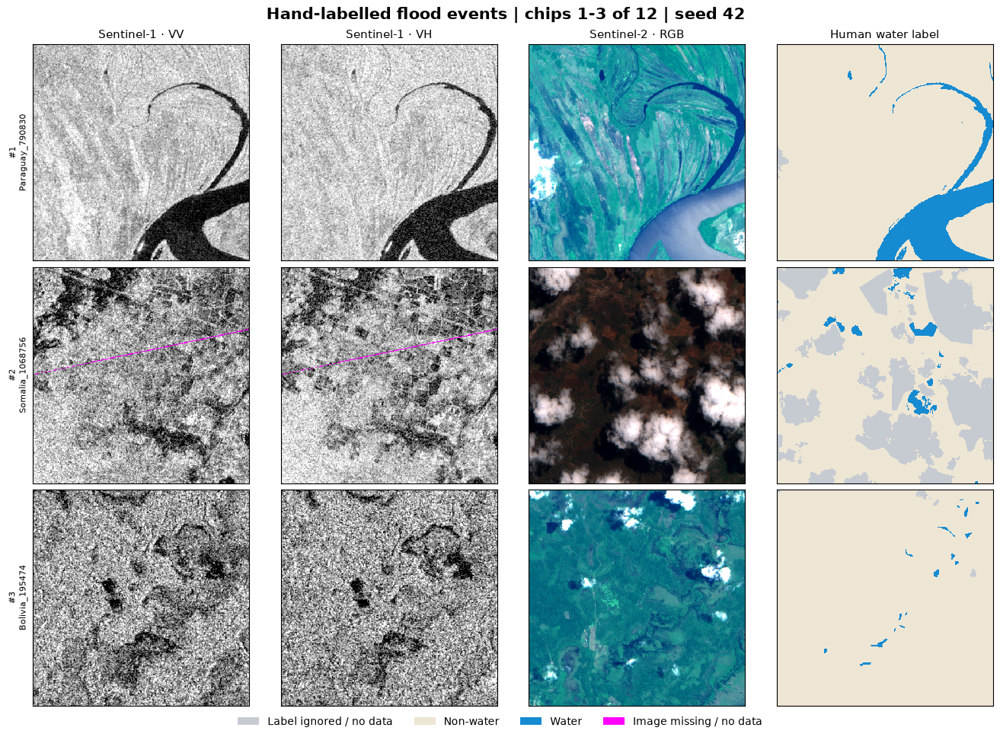

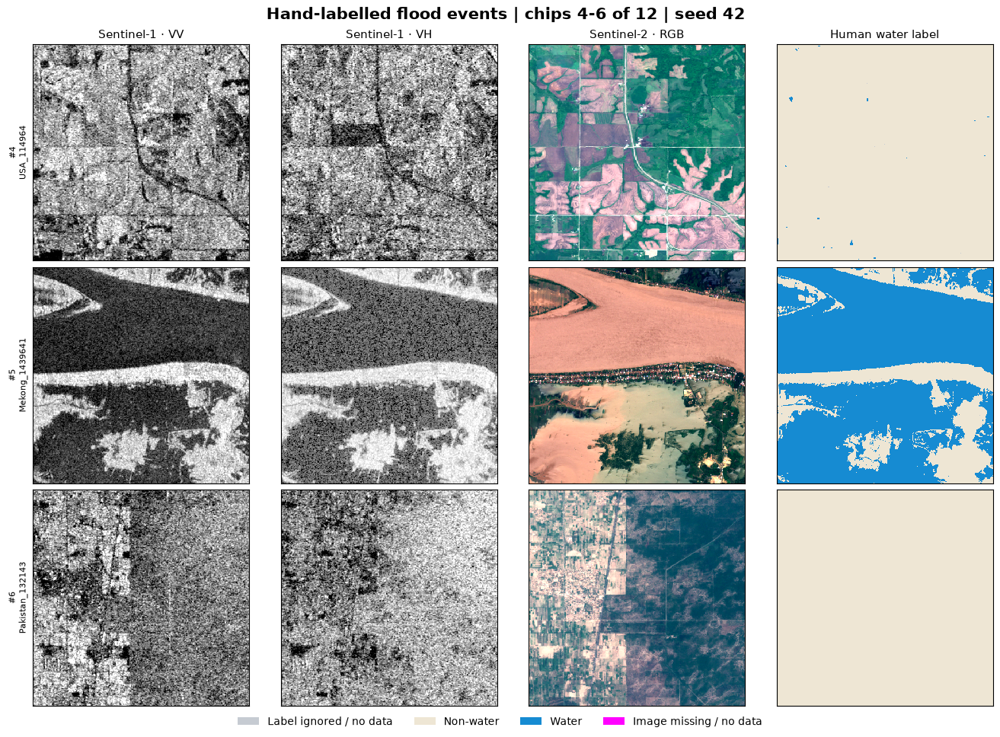

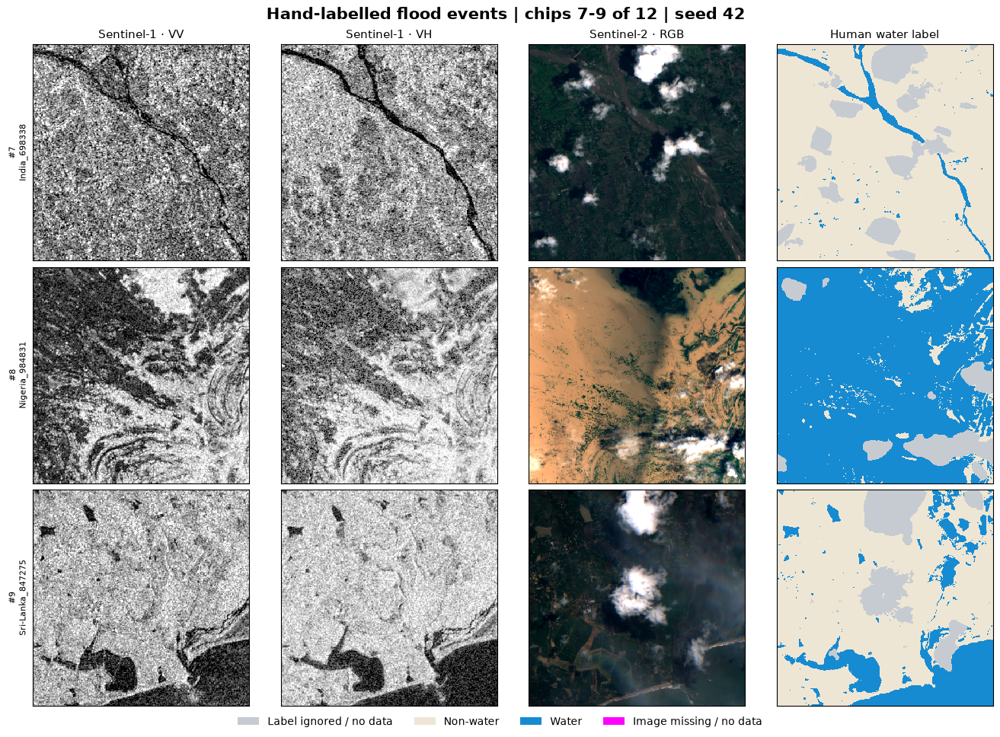

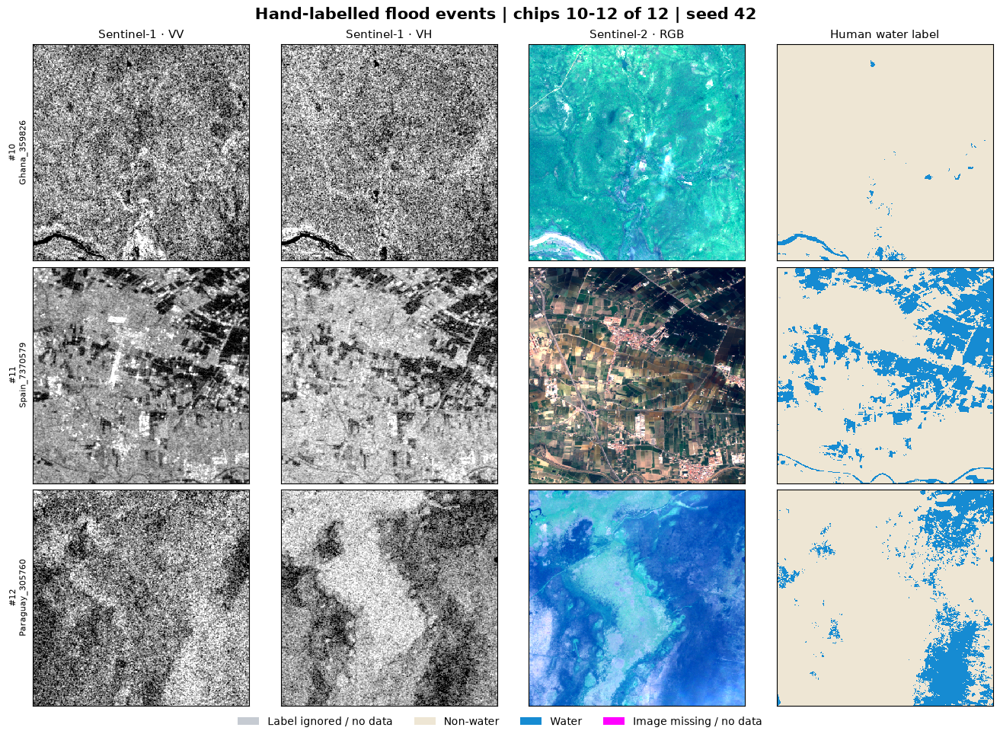

In [4]:
hand_samples = choose_samples(hand_records, mode="region_balanced")
describe_selection(hand_records, hand_samples, mode="region_balanced")
show_samples(hand_samples, [
    ("s1", "VV", "Sentinel-1 · VV"), ("s1", "VH", "Sentinel-1 · VH"),
    ("rgb", "rgb", "Sentinel-2 · RGB"), ("mask", "mask", "Human water label"),
], "Hand-labelled flood events")

## 2. Weakly labelled flood events
The two weak-supervision experiments use the same radar imagery with different label sources. These masks can disagree; neither panel is a model prediction.

Selected 12 of 4,384 chips | seed=42 | method=region_balanced

Region prefix       Available   Selected
Bolivia                   224          1
Colombia                  534          1
Ghana                     181          1
India                     467          1
Mekong                   1353          1
Nigeria                   109          1
Pakistan                  249          1
Paraguay                  316          1
Somalia                   129          1
Spain                     146          1
Sri-Lanka                 190          1
USA                       486          1

Row  Exact chip ID (same order as the figures)
  1  Bolivia_6482789
  2  Paraguay_3773828
  3  Pakistan_1811336
  4  Spain_3234783
  5  USA_8846992
  6  India_5679356
  7  Nigeria_9519064
  8  Ghana_4325636
  9  Mekong_1841048
 10  Sri-Lanka_487509
 11  Colombia_1175789
 12  Somalia_1745180


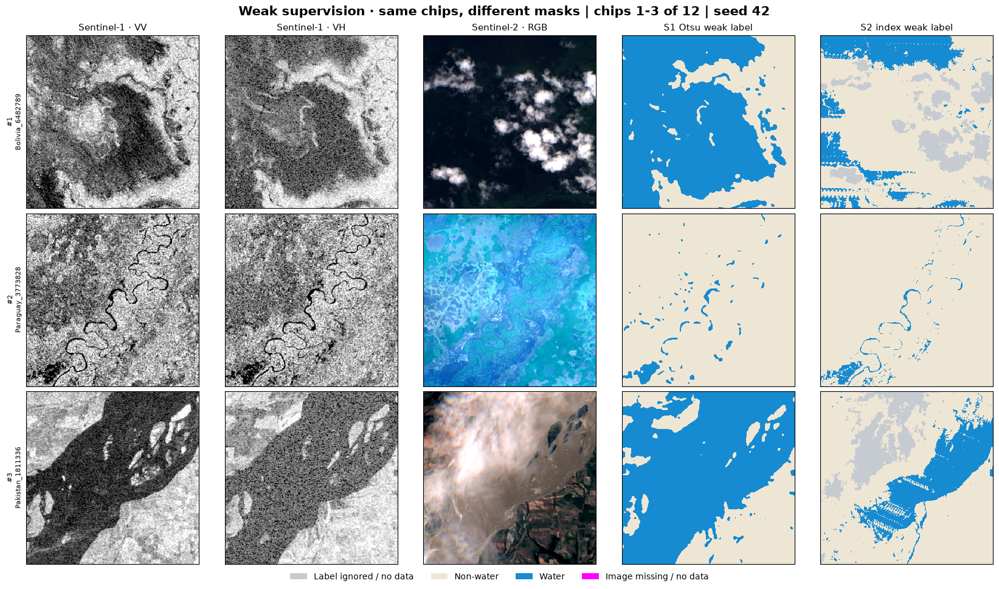

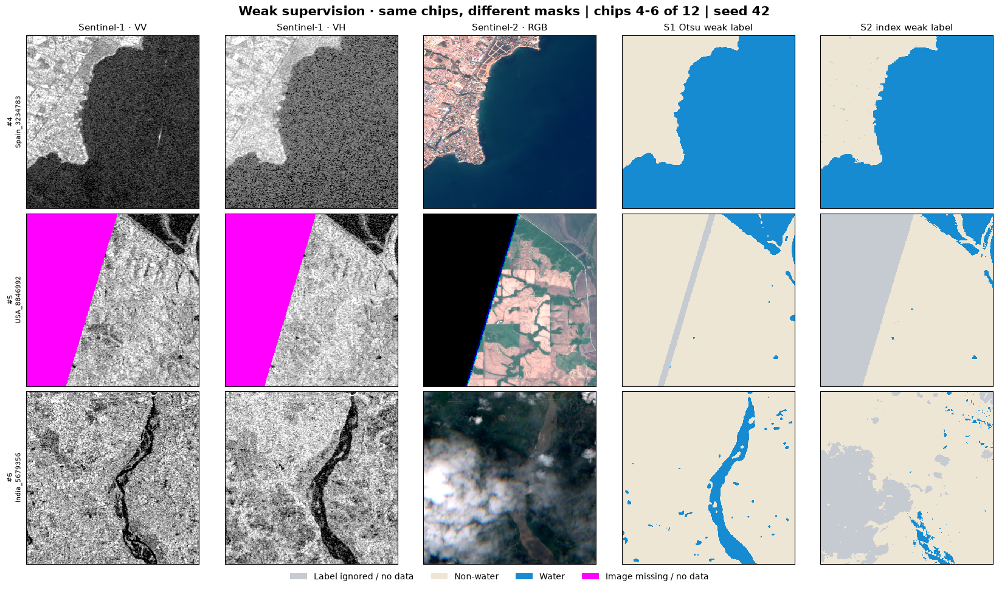

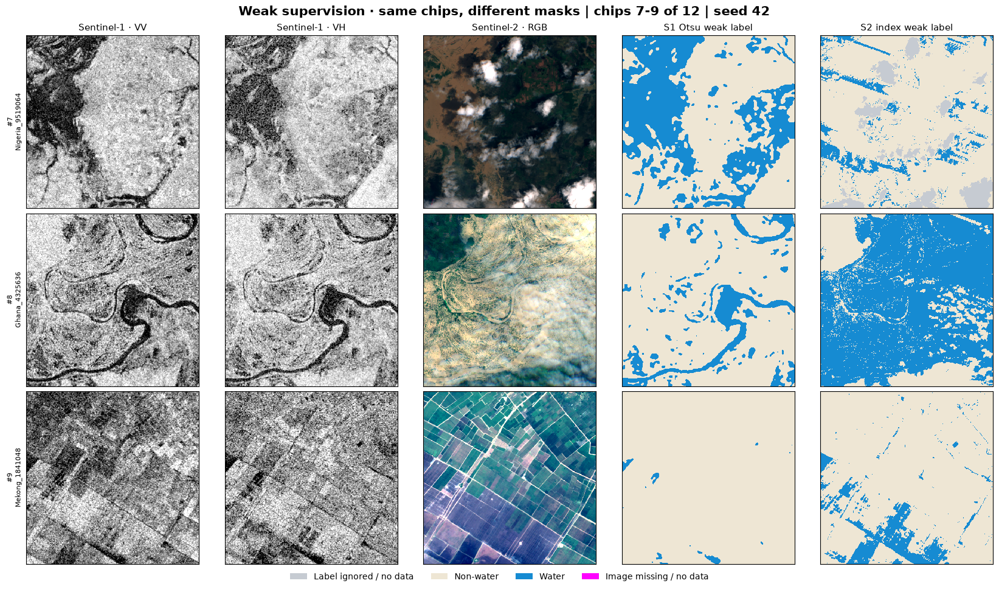

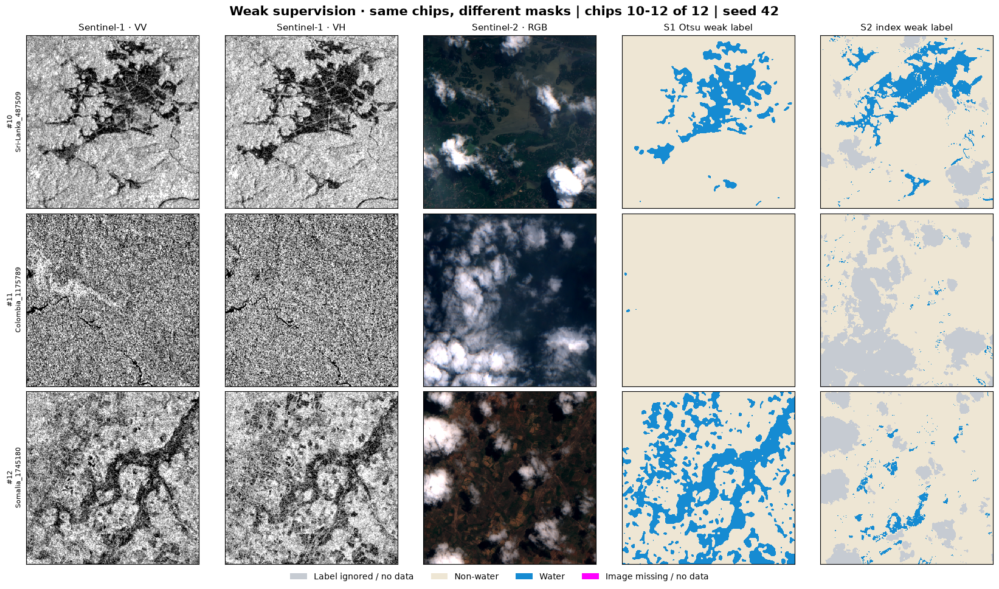

In [5]:
weak_samples = choose_samples(weak_records, mode="region_balanced")
describe_selection(weak_records, weak_samples, mode="region_balanced")
show_samples(weak_samples, [
    ("s1", "VV", "Sentinel-1 · VV"), ("s1", "VH", "Sentinel-1 · VH"),
    ("rgb", "rgb", "Sentinel-2 · RGB"),
    ("s1_mask", "mask", "S1 Otsu weak label"), ("s2_mask", "mask", "S2 index weak label"),
], "Weak supervision · same chips, different masks")

## 3. Permanent water
Radar input and JRC-derived targets. This collection has no accompanying Sentinel-2 RGB folder in the local download. Native tile sizes and aspect ratios are preserved.

Some source CSV rows pair different locations. Red-bordered panels identify spatial mismatches among the selected samples; the warning prints both filenames. The original CSV and training code are unchanged.

Selected 12 of 814 chips | seed=42 | method=random

Row  Exact chip ID (same order as the figures)
  1  sentinel_12_806_low_density_9.457579429417624_42.63138723090513
  2  sentinel_1_289_inhabited_107.13459824244651_-7.4648606778453015
  3  sentinel_1_4_inhabited_45.049477468369865_-12.745510968479103
  4  sentinel_13_431_inhabited_-110.8264752868386_25.633962880327466
  5  sentinel_1_280_rural_100.40428082203431_2.278190401013927
  6  sentinel_4_657_rural_120.44754765638082_31.023138772400035
  7  sentinel_5_364_low_density_-122.51286503220427_47.29484442652939
  8  sentinel_12_803_rural_-1.6508305556025193_37.37379941091976
  9  sentinel_4_687_inhabited_71.62321819121632_56.169797712303776
 10  sentinel_4_682_low_density_129.15803591800096_32.973130417678234
 11  sentinel_1_465_rural_-58.42449756896814_7.031337955227187
 12  sentinel_6_379_rural_-105.5636212685091_60.599134266217895
PAIRING WARNING: sentinel_1_4_inhabited_45.049477468369865_-12.745510968479103 -> water_1_4_rural_45.

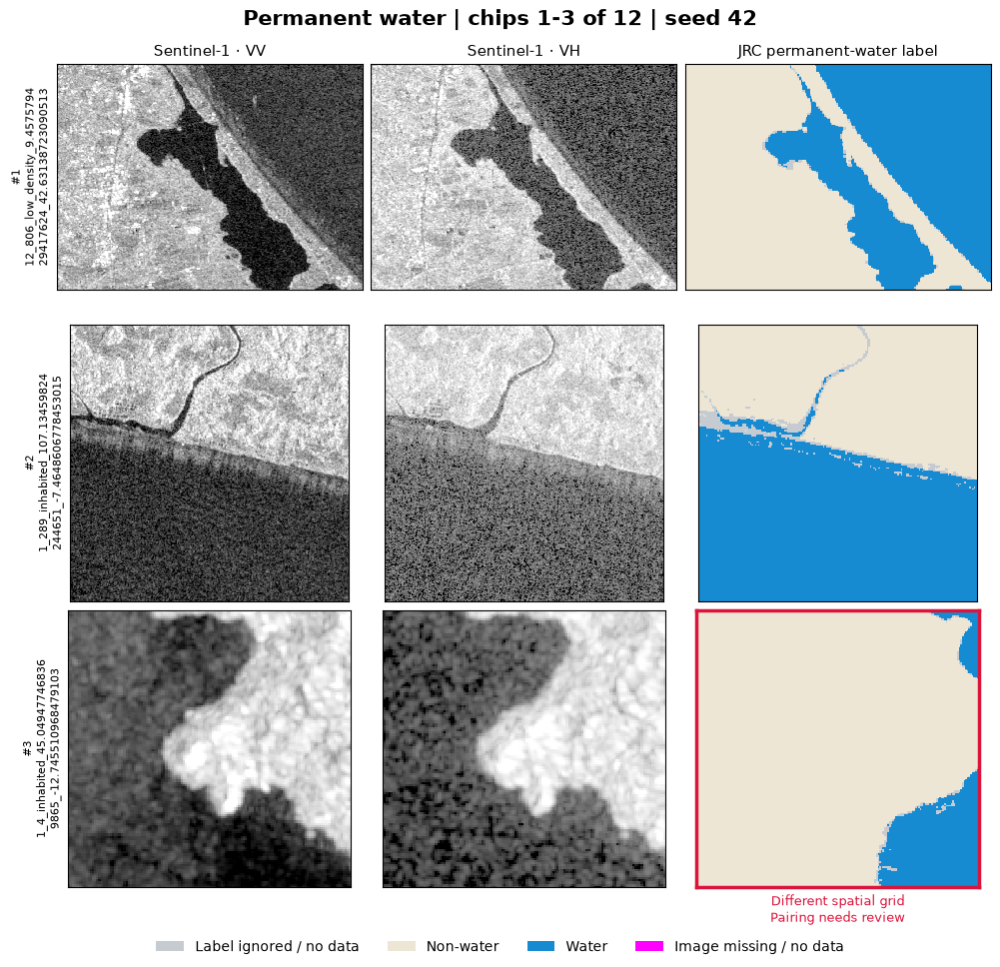

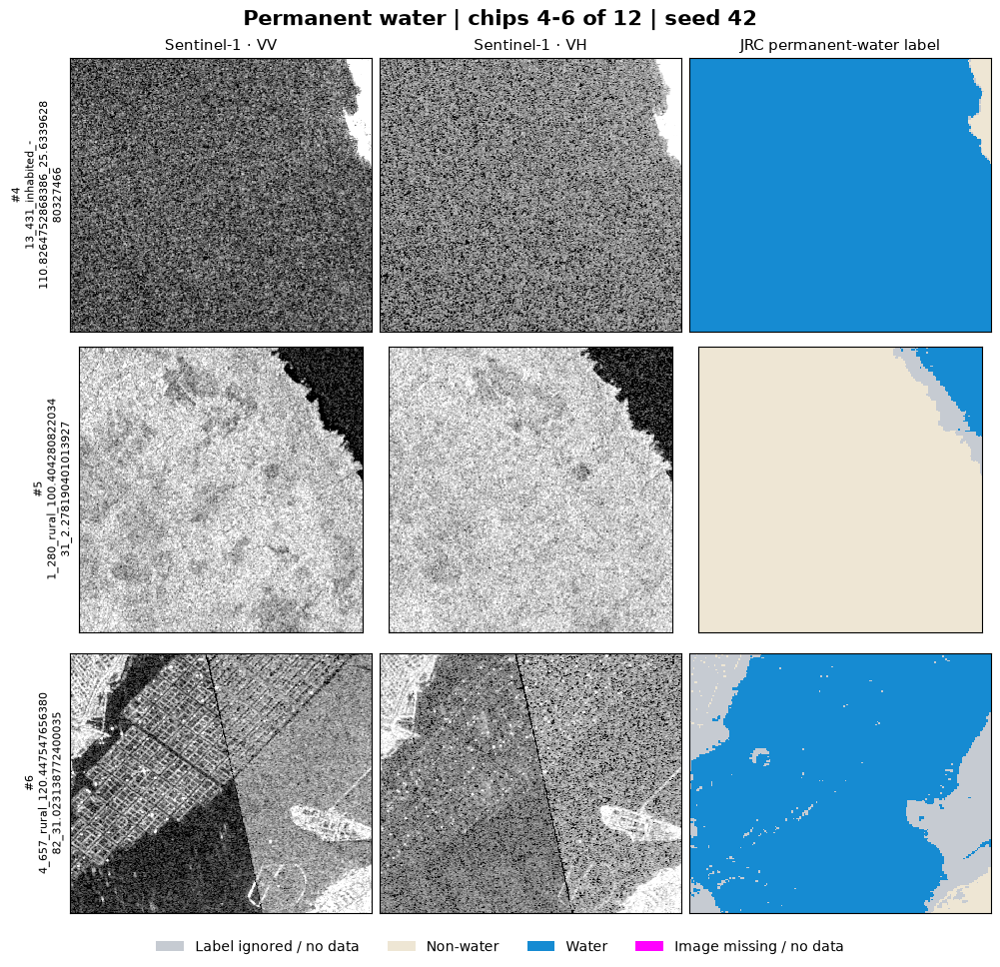

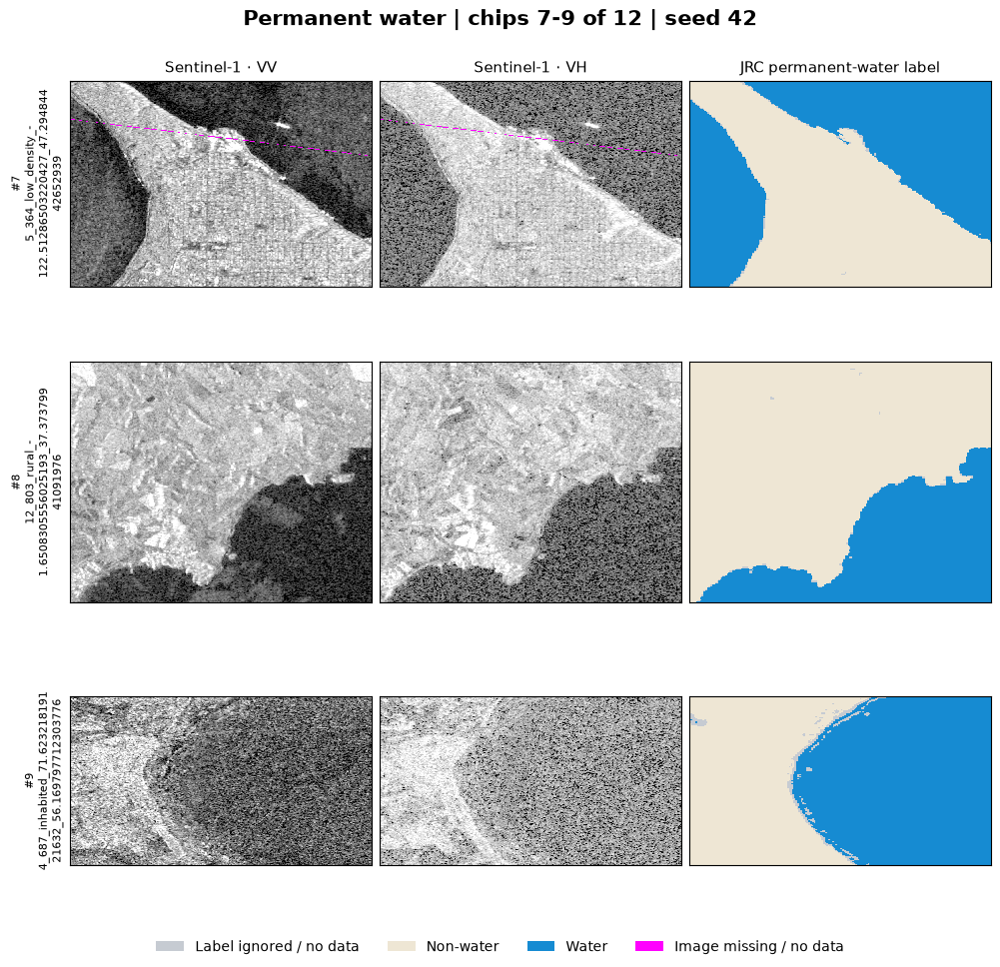

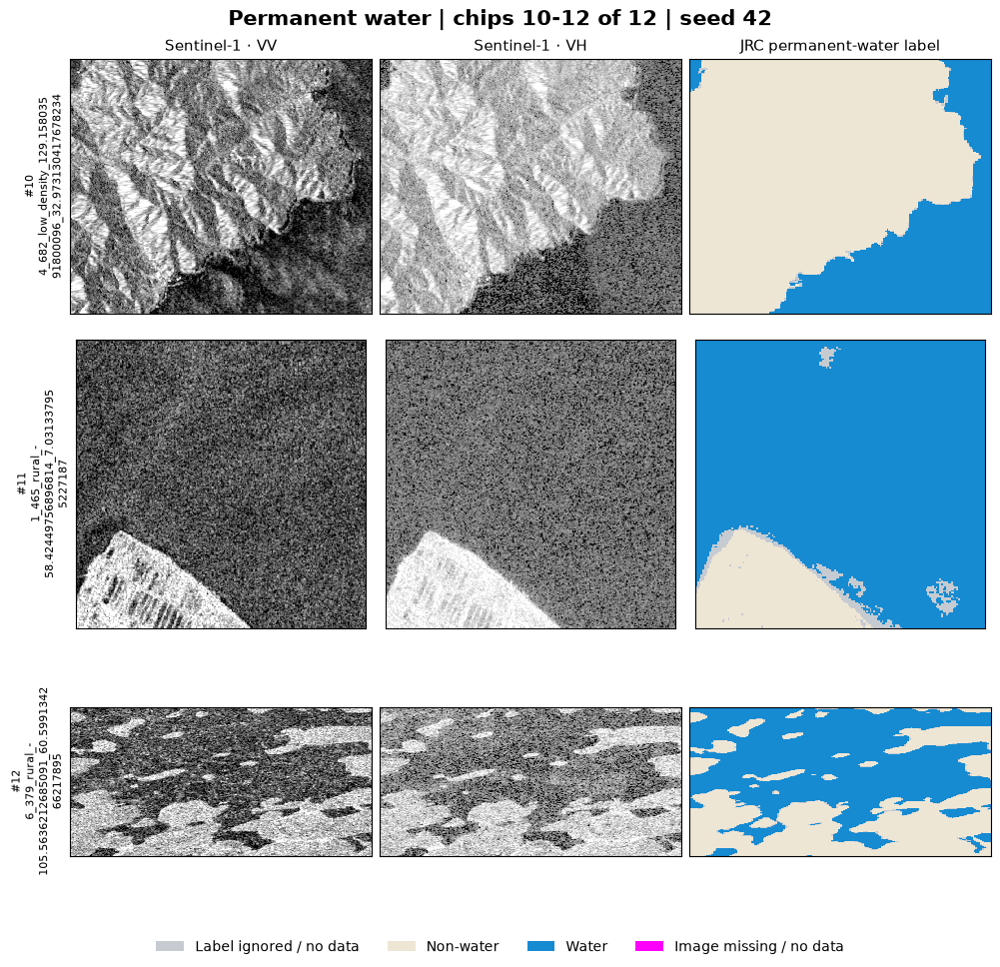

In [6]:
perm_samples = choose_samples(perm_records, mode="random")
describe_selection(perm_records, perm_samples, mode="random")
show_samples(perm_samples, [
    ("s1", "VV", "Sentinel-1 · VV"), ("s1", "VH", "Sentinel-1 · VH"),
    ("mask", "mask", "JRC permanent-water label"),
], "Permanent water")